### NOTE:
This is Aidan's Kaggle Notebooks code that was used to train the model

It's a bit old and probably won't run with Pixi

In [1]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

True Tesla T4


In [5]:
# the code that Roboflow supplied me with:
# !pip install roboflow
import os

local_dataset_path = "v2_EGH455-3"
if os.path.exists(local_dataset_path):
    DATA_YAML = f"{local_dataset_path}/data.yaml"
else:
  from roboflow import Roboflow
  rf = Roboflow(api_key="wVDEtKF69fLiZfjLLC3n")
  project = rf.workspace("bio-aidan-gmail-com").project("v2_egh455")
  version = project.version(3)
  dataset = version.download("yolo26")
  DATA_YAML = f"{dataset.location}/data.yaml"


!pip show roboflow


Name: roboflow
Version: 1.4.2
Summary: Official Python package for working with the Roboflow API
Home-page: https://github.com/roboflow-ai/roboflow-python
Author: Roboflow
Author-email: support@roboflow.com
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: certifi, click, cycler, filetype, idna, kiwisolver, matplotlib, numpy, opencv-python-headless, pi-heif, Pillow, pillow-avif-plugin, python-dateutil, python-dotenv, PyYAML, requests, requests_toolbelt, six, tqdm, typer, urllib3
Required-by: 


3 classes: ['closedValve', 'gauge', 'openValve']


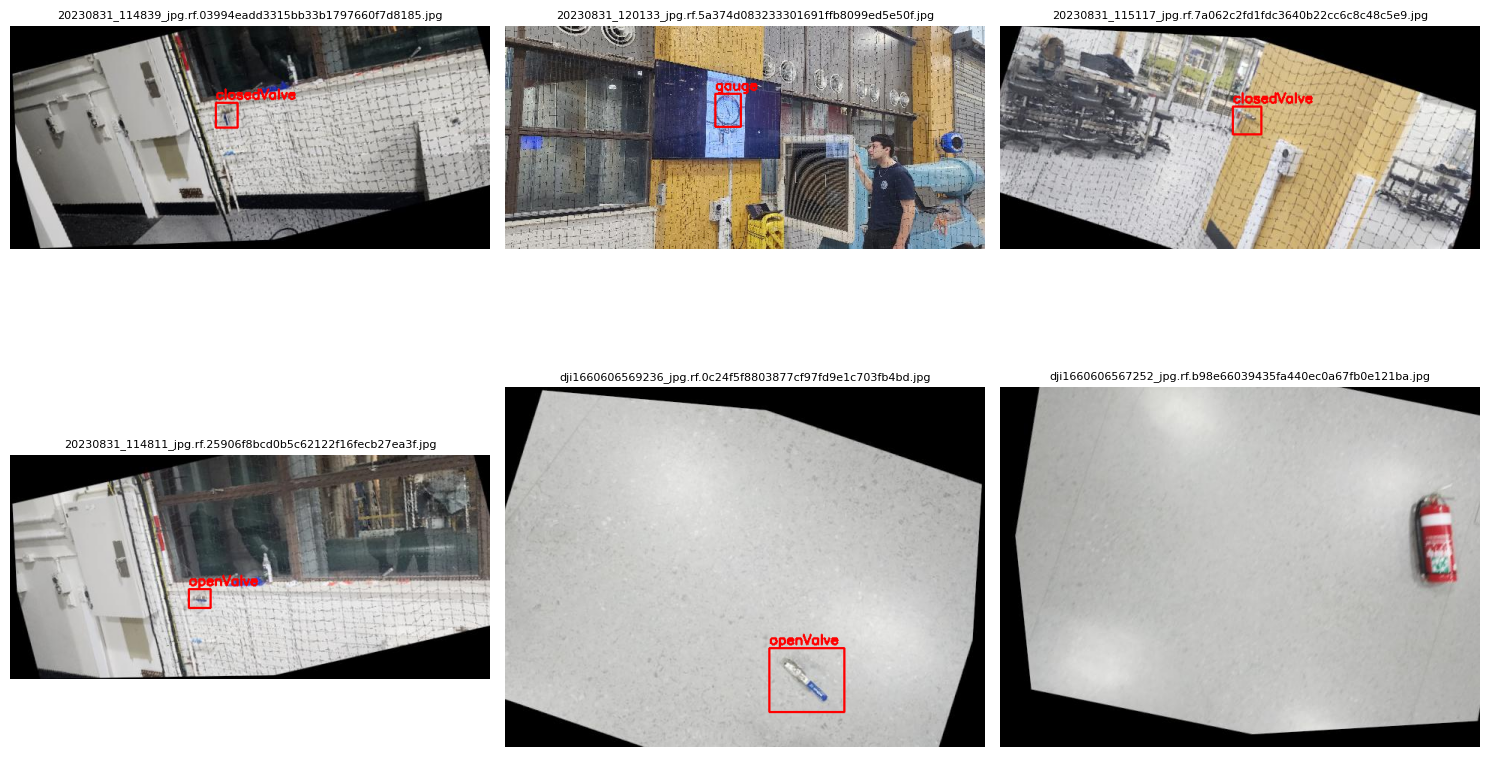

In [12]:
# viewing data
import yaml

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg["names"]
print(f"{len(class_names)} classes: {class_names}")

# 4. Sample images with boxes drawn
import os, random
import cv2
import matplotlib.pyplot as plt

train_img_dir = os.path.join(os.path.dirname(DATA_YAML), data_cfg["train"].replace("../", ""))
train_lbl_dir = train_img_dir.replace("images", "labels")

img_files = [f for f in os.listdir(train_img_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
sample = random.sample(img_files, min(6, len(img_files)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, fname in zip(axes.ravel(), sample):
    img = cv2.cvtColor(cv2.imread(os.path.join(train_img_dir, fname)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = os.path.join(train_lbl_dir, os.path.splitext(fname)[0] + ".txt")

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                cls, cx, cy, bw, bh = map(float, line.split())
                x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
                x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(img, class_names[int(cls)], (x1, max(y1 - 5, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    ax.imshow(img)
    ax.set_title(fname, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

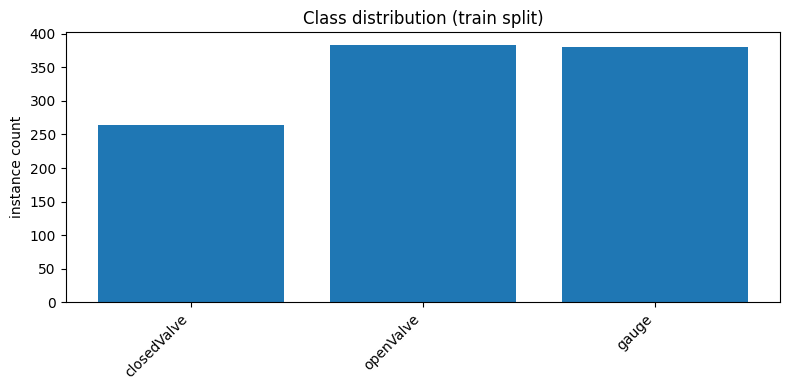

In [13]:
# 5. Class distribution
from collections import Counter

counts = Counter()
for fname in os.listdir(train_lbl_dir):
    with open(os.path.join(train_lbl_dir, fname)) as f:
        for line in f:
            cls_id = int(line.split()[0])
            counts[class_names[cls_id]] += 1

plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("instance count")
plt.title("Class distribution (train split)")
plt.tight_layout()
plt.show()

In [21]:
# 6. Train
# !pip install -q ultralytics

from ultralytics import YOLO

model = YOLO("yolo26n.pt")
model_name = "50_epochs"

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=32,
    patience=7,
    project="runs",
    name=model_name,
)


Ultralytics 8.4.143 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=v2_EGH455-3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=50_epochs, nbs=64, nms=None, opset=None, optimize=False

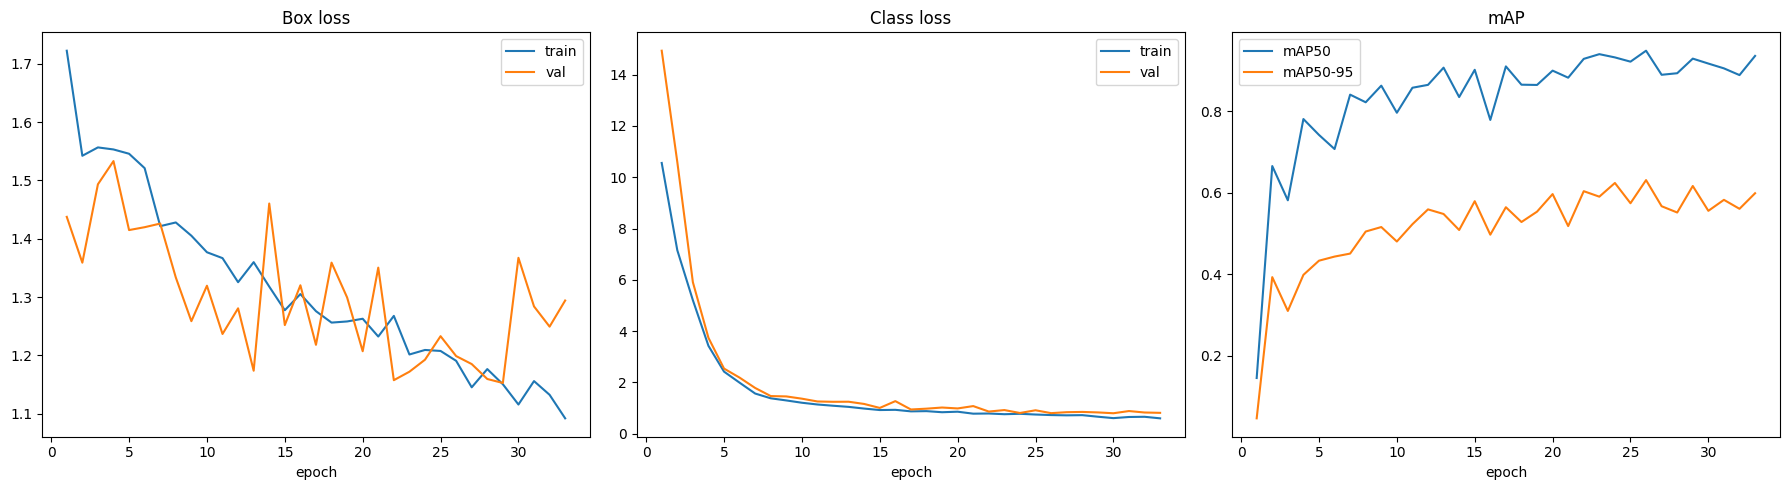

In [22]:
# Plot training curves from the run's results.csv
import pandas as pd

results_csv = f"runs/detect/runs/{model_name}/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"], label="val")
axes[0].set_title("Box loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"], label="val")
axes[1].set_title("Class loss")
axes[1].set_xlabel("epoch")
axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[2].set_title("mAP")
axes[2].set_xlabel("epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

Ultralytics 8.4.143 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1284.1±303.7 MB/s, size: 44.0 KB)
val: Scanning /kaggle/working/v2_EGH455-3/test/labels.cache... 68 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 28.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.8it/s 1.3s0.4s
                   all         68         50      0.908      0.909      0.888      0.558
           closedValve          8          8      0.849      0.875      0.781      0.463
                 gauge         19         19      0.968          1      0.995      0.809
             openValve         23         23      0.907      0.853      0.887      0.402
Speed: 3.2ms preprocess, 4.3ms inference, 0.0ms loss, 5.5ms postprocess per image
Results saved to /kaggle/working/runs/dete

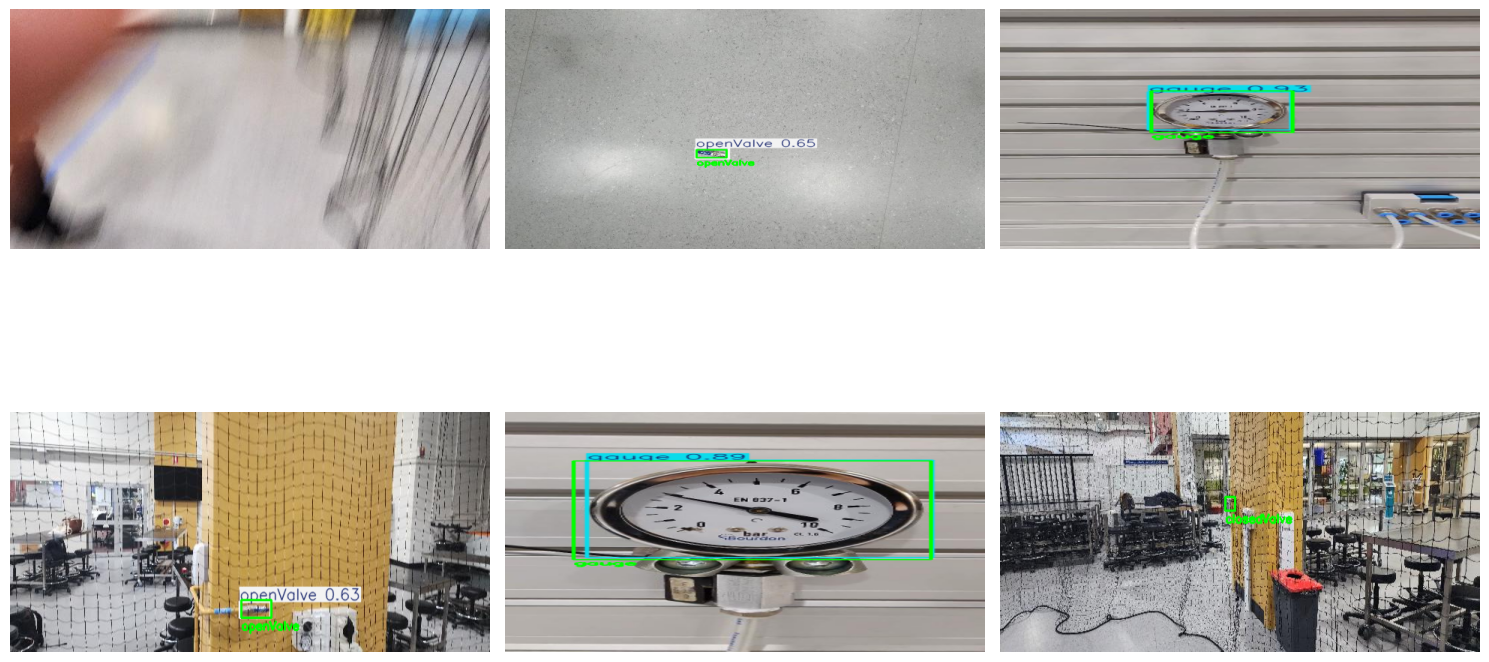

In [24]:
# 7. Validate (on test split)
model_path = f"runs/detect/runs/{model_name}/weights/best.pt"
best_model = YOLO(model_path)
metrics = best_model.val(data=DATA_YAML, split="test")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"mAP50: {metrics.box.map50:.3f}")

# 8. Inference on test samples (predictions in default color, ground truth in green)
random.seed(11) #42 is NICE!
test_img_dir = os.path.join(os.path.dirname(DATA_YAML), data_cfg["test"].replace("../", ""))
test_lbl_dir = test_img_dir.replace("images", "labels")
test_samples = random.sample(os.listdir(test_img_dir), min(6, len(os.listdir(test_img_dir))))

preds = best_model.predict([os.path.join(test_img_dir, f) for f in test_samples], conf=0.25)

PLOT_SIZE = (640, 320)  # (width, height) all images get resized to before display

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, fname, pred in zip(axes.ravel(), test_samples, preds):
    img = pred.plot()  # predictions drawn by ultralytics
    h, w = img.shape[:2]

    lbl_path = os.path.join(test_lbl_dir, os.path.splitext(fname)[0] + ".txt")
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                cls, cx, cy, bw, bh = map(float, line.split())
                x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
                x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # green = ground truth
                cv2.putText(img, class_names[int(cls)], (x1, min(y2 + 15, h - 5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), PLOT_SIZE)
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [26]:
from IPython.display import FileLink
FileLink(model_path)

/kaggle/working/runs/detect/runs/50_epochs/weights/best.pt